In [210]:
import nest_asyncio
nest_asyncio.apply()  # Required for Gremlin driver in Jupyter (avoids "event loop already running" error)

from pathlib import Path
from dotenv import load_dotenv

# Load .env from agents folder
env_path = Path.cwd() / '.env'
if not env_path.exists():
    env_path = Path.cwd() / 'backend' / 'agents' / '.env'
if env_path.exists():
    load_dotenv(dotenv_path=env_path)
    print(f"✓ Loaded .env from: {env_path}")
else:
    print("⚠ .env not found in agents folder")

✓ Loaded .env from: /Users/rob.bajra/Projects/voice-to-rag/backend/agents/.env


In [211]:
from puppygraph import PuppyGraphClient, PuppyGraphHostConfig
client = PuppyGraphClient(PuppyGraphHostConfig("localhost"))
client.gremlin_query("g.V('table[00vsdb.agent_analytics.agents_clean]').bothE('lineage').path()")


[path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[651c8d73-4a3c-35e4-96ab-61df5aa15568]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]],
 path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[dcd982d2-5bd9-351f-bb31-0fca2278c9b9]][table[00vsdb.agent_analytics.agents_bronze]-lineage->table[00vsdb.agent_analytics.agents_clean]]]]

In [212]:

# Databricks model setup (E2 demo workspace)
from openai import OpenAI

ai_client = OpenAI(
  api_key=os.getenv("DATABRICKS_TOKEN"), # your personal access token
  base_url=os.getenv("DATABRICKS_HOST") + "serving-endpoints", # your Databricks workspace instance
)


In [213]:
# PuppyGraph tools (reload to pick up changes)
import importlib
import gremlin_tool
import graph_viz_tool
importlib.reload(gremlin_tool)
importlib.reload(graph_viz_tool)

from gremlin_tool import (
    GENERATE_GREMLIN_TOOL_SPEC, generate_gremlin,
    EXECUTE_GREMLIN_TOOL_SPEC, execute_gremlin,
)
from graph_viz_tool import (
    VISUALIZE_LINEAGE_TOOL_SPEC, visualize_lineage,
)

# Tool specs (dicts for the OpenAI API) and local functions
TOOLS = [GENERATE_GREMLIN_TOOL_SPEC, EXECUTE_GREMLIN_TOOL_SPEC, VISUALIZE_LINEAGE_TOOL_SPEC]



In [214]:
import json

def AGENT(user_query: str):
    # Map tool names to their local Python functions
    TOOL_FUNCTIONS = {
        "generate_gremlin": generate_gremlin,
        "execute_gremlin": execute_gremlin,
        "visualize_lineage": visualize_lineage,
    }

    LLM_ENDPOINT_NAME = "databricks-claude-sonnet-4-5"
    MAX_TOOL_ROUNDS = 5  # safety limit to avoid infinite loops

    messages = [
        {
            "role": "system",
            "content": """
            You are a PuppyGraph agent.
            Before each action, explain your reasoning step by step.
            Use the generate_gremlin tool to convert natural language questions into Gremlin queries.
            Then use the execute_gremlin tool to run the query and return results.
            Always call execute_gremlin after generate_gremlin to get the actual data.
            When the user asks about lineage, data flow, or graph relationships,
            also call visualize_lineage with the same Gremlin query to render an
            inline graph visualization.
            """,
        },
        {
            "role": "user",
            "content": user_query,
        },
    ]

    # Agentic loop: keep calling the LLM until it stops requesting tool calls
    for round_num in range(MAX_TOOL_ROUNDS):
        response = ai_client.chat.completions.create(
            messages=messages,
            model=LLM_ENDPOINT_NAME,
            tools=TOOLS,
            max_tokens=1024,
        )

        choice = response.choices[0]

        if choice.finish_reason != "tool_calls":
            # Model is done — print final answer
            print("Final answer:", choice.message.content)
            break

        # Process tool calls
        messages.append(choice.message)

        for tool_call in choice.message.tool_calls:
            fn_name = tool_call.function.name
            fn_args = json.loads(tool_call.function.arguments)
            print(f"[Round {round_num + 1}] Tool call: {fn_name}({fn_args})")

            result = TOOL_FUNCTIONS[fn_name](**fn_args)
            print(f"[Round {round_num + 1}] Tool result: {result}\n")

            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "content": result,
            })
    else:
        print("⚠ Reached max tool rounds without a final answer")


## Lineage Q&A with agent

In [221]:
AGENT("List 10 tables with at least 5 dependencies")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').limit(100).count()).where(select('deg').is(gte(5))).order().by(select('deg'), desc).limit(10)"})
[Round 1] Tool result: g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').limit(100).count()).where(select('deg').is(gte(5))).order().by(select('deg'), desc).limit(10)

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').limit(100).count()).where(select('deg').is(gte(5))).order().by(select('deg'), desc).limit(10)"})
[Round 2] Tool result: [{"deg": 5, "id": "table[adam_farley.money_puck.skaters_raw]"}]

Final answer: Based on the query results, I found only **1 table** that has at least 5 dependencies:

| Table ID | Number of Dependencies |
|----------|----------------------|
| **table[adam_farley.money_puck.skaters_raw]** | 5 |

This table has exactly 5 lineage c

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').bothE('lineage').path().limit(100)"})
[Round 1] Tool result: g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').bothE('lineage').path().limit(100)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').bothE('lineage').path().limit(100)"})
[Round 1] Tool result: ["path[v[table[uc_rabi.dbdemos_retail_c360.churn_orders]], e[lineage[b1cad7bb-75b4-3590-8a14-cd116a2754ea]][table[uc_rabi.dbdemos_retail_c360.churn_orders]-lineage->table[uc_rabi.dbdemos_retail_c360.__metric_view_mat_8a22d3c8-796f-4070-8abd-72655e27b71f_churn_features]]]", "path[v[table[uc_rabi.dbdemos_retail_c360.churn_orders]], e[lineage[16291993-ab5d-3322-bcee-1159f0089ee7]][table[uc_rabi.dbdemos_retail_c360.churn_orders]-lineage->table[uc_rabi.dbdemos_retail_c360.churn_orders]]]", "path[v[table[uc_rabi.dbdemos_retail_c360.churn_orders]], e[lineage[d41f3c

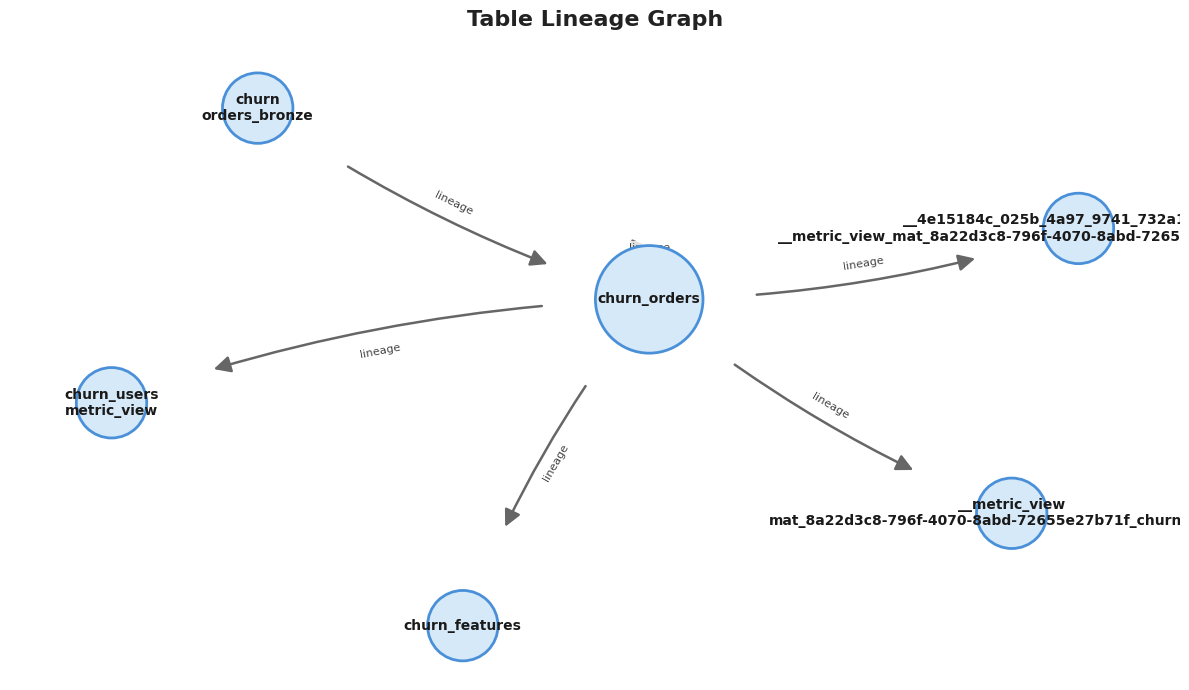

[Round 1] Tool result: Lineage graph rendered: 6 nodes (churn_orders, __metric_view_mat_8a22d3c8-796f-4070-8abd-72655e27b71f_churn_features, churn_features, churn_users_metric_view, __4e15184c_025b_4a97_9741_732a1badb39b___metric_view_mat_8a22d3c8-796f-4070-8abd-72655e27b71f_churn_features, churn_orders_bronze), 6 edges.

Final answer: Perfect! I've successfully retrieved and visualized the lineage for the table `uc_rabi.dbdemos_retail_c360.churn_orders`. 

## Summary of Lineage:

The lineage graph shows **6 connected tables** with **6 lineage relationships**:

### Upstream (Source):
- **churn_orders_bronze** → churn_orders

### Downstream (Targets):
- churn_orders → **churn_features**
- churn_orders → **churn_users_metric_view**
- churn_orders → **__metric_view_mat_8a22d3c8-796f-4070-8abd-72655e27b71f_churn_features**
- churn_orders → **__4e15184c_025b_4a97_9741_732a1badb39b___metric_view_mat_8a22d3c8-796f-4070-8abd-72655e27b71f_churn_features**

### Self-reference:
- churn_orders → *

In [222]:
AGENT("show lineage of uc_rabi.dbdemos_retail_c360.churn_orders")

In [223]:
AGENT("How many unique tables are upsteam of uc_rabi.dbdemos_retail_c360.churn_orders")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').inE('lineage').outV().dedup().count()"})
[Round 1] Tool result: g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').inE('lineage').outV().dedup().count()

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').inE('lineage').outV().dedup().count()"})
[Round 1] Tool result: [3]

Final answer: There are **3 unique tables** upstream of `uc_rabi.dbdemos_retail_c360.churn_orders`.

This means that 3 distinct tables directly feed data into the `churn_orders` table through lineage relationships.

Would you like me to show you which specific tables are upstream, or visualize the lineage graph?


[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').inE('lineage').outV().path()"})
[Round 1] Tool result: g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').inE('lineage').outV().path()

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('table[uc_rabi.dbdemos_retail_c360.churn_orders]').inE('lineage').outV().path()"})
[Round 1] Tool result: ["path[v[table[uc_rabi.dbdemos_retail_c360.churn_orders]], e[lineage[16291993-ab5d-3322-bcee-1159f0089ee7]][table[uc_rabi.dbdemos_retail_c360.churn_orders]-lineage->table[uc_rabi.dbdemos_retail_c360.churn_orders]], v[table[uc_rabi.dbdemos_retail_c360.churn_orders]]]", "path[v[table[uc_rabi.dbdemos_retail_c360.churn_orders]], e[lineage[395d8ddf-e355-324c-8edf-ecd2f1b89131]][table[uc_rabi.dbdemos_retail_c360.churn_orders_bronze]-lineage->table[uc_rabi.dbdemos_retail_c360.churn_orders]], v[table[uc_rabi.dbdemos_retail_c360.churn_orders_bronze]]]"]

[Round 1] Tool call: visualize

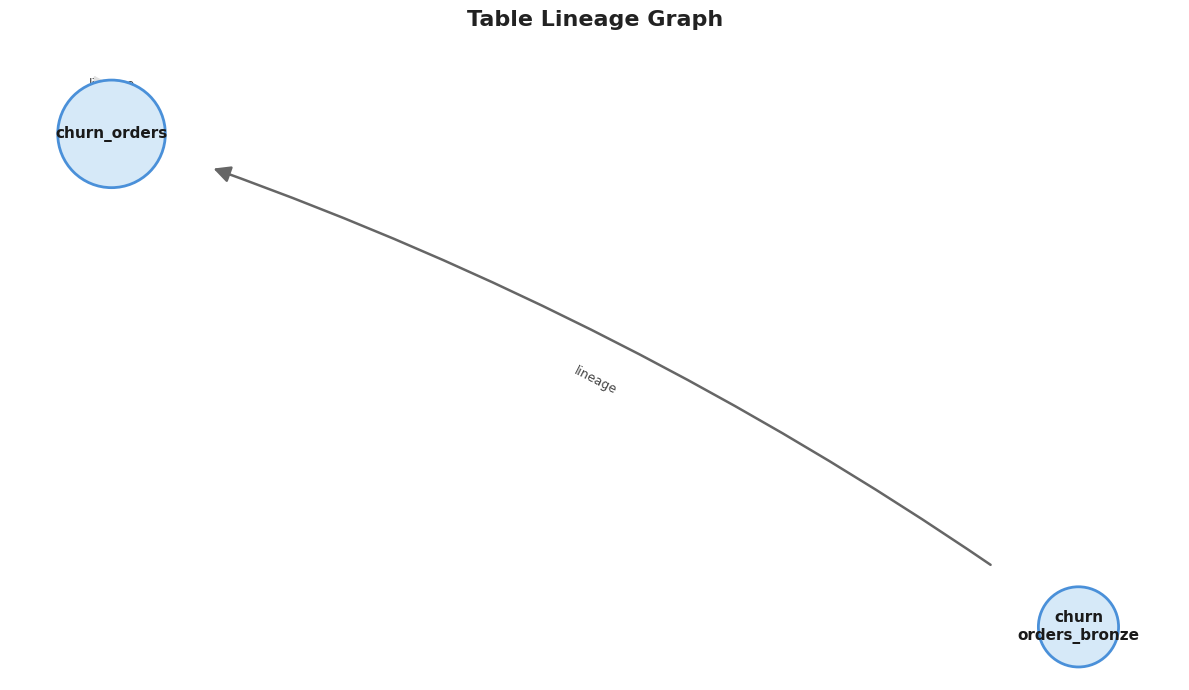

[Round 1] Tool result: Lineage graph rendered: 2 nodes (churn_orders, churn_orders_bronze), 2 edges.

Final answer: Perfect! I found the upstream lineage for `uc_rabi.dbdemos_retail_c360.churn_orders`. 

## Results:

The table **`churn_orders`** has **2 upstream dependencies**:

1. **`uc_rabi.dbdemos_retail_c360.churn_orders_bronze`** - This is a source table that feeds data into `churn_orders`
2. **`uc_rabi.dbdemos_retail_c360.churn_orders`** (self-reference) - The table also has a lineage edge to itself, which typically indicates an incremental update or self-join operation

The visualization above shows the data flow, where:
- **`churn_orders_bronze`** → **`churn_orders`** (the bronze layer feeding into the processed table)
- **`churn_orders`** → **`churn_orders`** (self-referential lineage)

This is a typical pattern in medallion architecture where bronze tables (raw data) are transformed into silver/gold tables (refined data), and the table may also reference itself for incrementa

In [224]:
AGENT("Show upstream lineage of uc_rabi.dbdemos_retail_c360.churn_orders")

In [173]:
AGENT("What is the most connected table")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).order().by(select('deg'), desc).limit(1)"})
[Round 1] Tool result: g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).order().by(select('deg'), desc).limit(1)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).order().by(select('deg'), desc).limit(1)"})
[Round 1] Tool result: [{"deg": 4000, "id": "table[jack_test.health_demo.my_first_dbt_model]"}]

Final answer: The most connected table is **`jack_test.health_demo.my_first_dbt_model`** with **4,000 lineage connections** (combined incoming and outgoing edges).

This table appears to be a central hub in your data lineage, likely serving as either:
- A key transformation layer that aggregates data from many sources
- A foundational model that feeds many downstream tables
- Or both



In [174]:
AGENT("What are the top 5 tables with the most downstream lineage")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').project('table_id', 'downstream_count').by(id()).by(outE('lineage').count()).order().by(select('downstream_count'), desc).limit(5)"})
[Round 1] Tool result: g.V().hasLabel('table').project('table_id', 'downstream_count').by(id()).by(outE('lineage').count()).order().by(select('downstream_count'), desc).limit(5)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').project('table_id', 'downstream_count').by(id()).by(outE('lineage').count()).order().by(select('downstream_count'), desc).limit(5)"})
[Round 1] Tool result: [{"downstream_count": 4000, "table_id": "table[jack_test.health_demo.my_first_dbt_model]"}, {"downstream_count": 3145, "table_id": "table[system.__internal_logging.payload_logs]"}, {"downstream_count": 1815, "table_id": "table[user_catalog.user_schema.rawesuser]"}, {"downstream_count": 905, "table_id": "table[samples.nyctaxi.trips]"}, {"downstream_count": 687, "table

In [175]:
AGENT("What are the top 5 tables with the most upstream lineage")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'upstream_count').by(id()).by(inE('lineage').count()).order().by(select('upstream_count'), desc).limit(5)"})
[Round 1] Tool result: g.V().hasLabel('table').project('id', 'upstream_count').by(id()).by(inE('lineage').count()).order().by(select('upstream_count'), desc).limit(5)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'upstream_count').by(id()).by(inE('lineage').count()).order().by(select('upstream_count'), desc).limit(5)"})
[Round 1] Tool result: [{"id": "table[system.data_classification.__table_statuses]", "upstream_count": 471}, {"id": "table[system.data_classification.__class_tag_applications]", "upstream_count": 239}, {"id": "table[system.data_classification.results]", "upstream_count": 238}, {"id": "table[sk_ml_handson.sk_schema.nyctaxi__sink_master]", "upstream_count": 89}, {"id": "table[sqlserver-profiler-runs.covetrus_run_jul2025_all

In [225]:
AGENT("Show 5 tables that have 5 dependencies ")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).where(select('deg').is(5)).limit(5)"})
[Round 1] Tool result: g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).where(select('deg').is(5)).limit(5)

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).where(select('deg').is(5)).limit(5)"})
[Round 2] Tool result: [{"deg": 5, "id": "table[seif_demo.dbdemos_dbt_retail.dbt_c360_silver_orders]"}, {"deg": 5, "id": "table[seif_demo.fsi_credit.credit_decisioning_features]"}, {"deg": 5, "id": "table[seif_demo.fsi_credit.customer_gold]"}, {"deg": 5, "id": "table[seif_demo.fsi_credit.customer_gold]"}, {"deg": 5, "id": "table[seif_demo.fsi_credit.fund_trans_gold]"}]

Final answer: Perfect! I found 5 tables that each have exactly 5 dependencies (lineage connections). Here are the results:

1. 

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[dbdemos_karla.hls_readmission_demo.condition_occurrence]').repeat(bothE('lineage').otherV().simplePath()).times(4).path().limit(100)"})
[Round 1] Tool result: g.V('table[dbdemos_karla.hls_readmission_demo.condition_occurrence]').repeat(bothE('lineage').otherV().simplePath()).times(4).path().limit(100)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('table[dbdemos_karla.hls_readmission_demo.condition_occurrence]').repeat(bothE('lineage').otherV().simplePath()).times(4).path().limit(100)"})
[Round 1] Tool result: ["path[v[table[dbdemos_karla.hls_readmission_demo.condition_occurrence]], e[lineage[b20bf4b7-33d9-3392-845d-1a8cd61f7b9e]][table[dbdemos_karla.hls_readmission_demo.conditions]-lineage->table[dbdemos_karla.hls_readmission_demo.condition_occurrence]], v[table[dbdemos_karla.hls_readmission_demo.conditions]], e[lineage[2f3a1031-20d9-3fbf-8d6e-4d5dca362544]][table[dbdemos_karla.hls_readmission_demo.condi

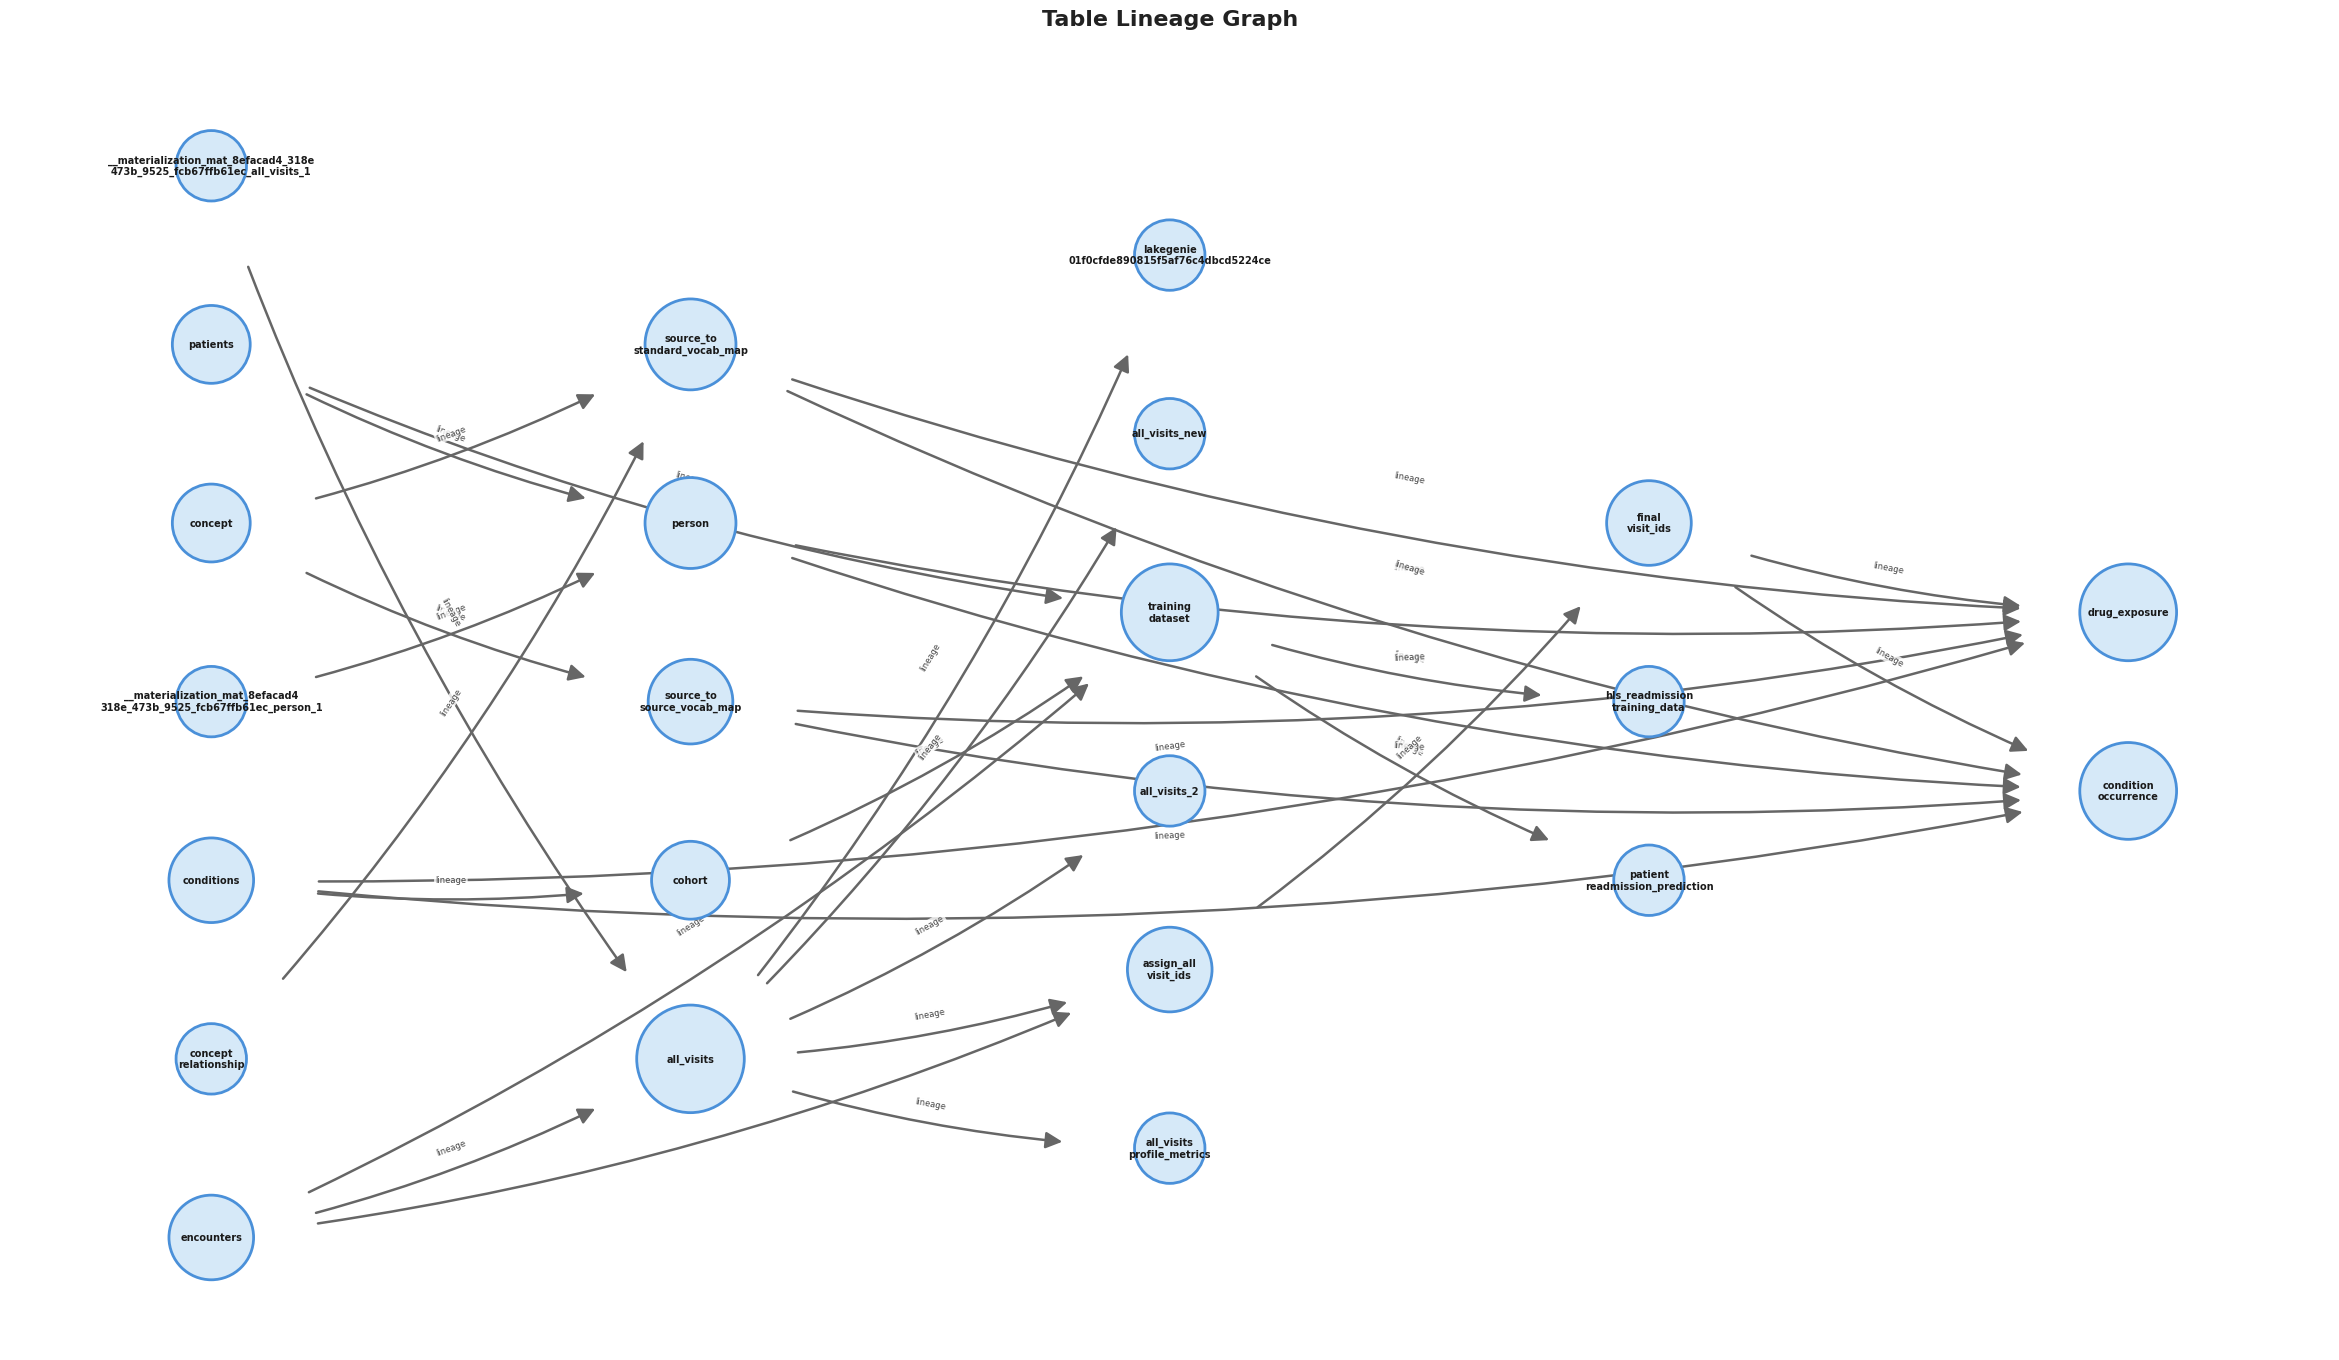

[Round 1] Tool result: Lineage graph rendered: 23 nodes (condition_occurrence, conditions, cohort, training_dataset, hls_readmission_training_data, patient_readmission_prediction, person, patients, source_to_source_vocab_map, concept, source_to_standard_vocab_map, drug_exposure, final_visit_ids, assign_all_visit_ids, encounters, all_visits, all_visits_new, lakegenie_01f0cfde890815f5af76c4dbcd5224ce, all_visits_2, all_visits_profile_metrics, concept_relationship, __materialization_mat_8efacad4_318e_473b_9525_fcb67ffb61ec_person_1, __materialization_mat_8efacad4_318e_473b_9525_fcb67ffb61ec_all_visits_1), 30 edges.

Final answer: Perfect! I've successfully retrieved and visualized the lineage of `dbdemos_karla.hls_readmission_demo.condition_occurrence` up to 4 levels.

## Summary

The query found **100 different lineage paths** (limited to 100 for performance) exploring up to 4 hops from the `condition_occurrence` table. The visualization shows:

### Key Findings:

**23 Connected Tables**

In [226]:
AGENT("Show lineage of dbdemos_karla.hls_readmission_demo.condition_occurrence up to 4 levels")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[mcutini_tuva.core._stg_claims_medical_claim]').inE('lineage').as('edge').outV().as('upstream').select('upstream', 'edge').by(id()).by(values('entity_type')).limit(20)"})
[Round 1] Tool result: g.V('table[mcutini_tuva.core._stg_claims_medical_claim]').inE('lineage').as('edge').outV().as('upstream').select('upstream', 'edge').by(id()).by(values('entity_type')).limit(20)

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V('table[mcutini_tuva.core._stg_claims_medical_claim]').inE('lineage').as('edge').outV().as('upstream').select('upstream', 'edge').by(id()).by(values('entity_type')).limit(20)"})
[Round 2] Tool result: []

[Round 2] Tool call: visualize_lineage({'gremlin_query': "g.V('table[mcutini_tuva.core._stg_claims_medical_claim]').inE('lineage').outV().path().limit(20)"})


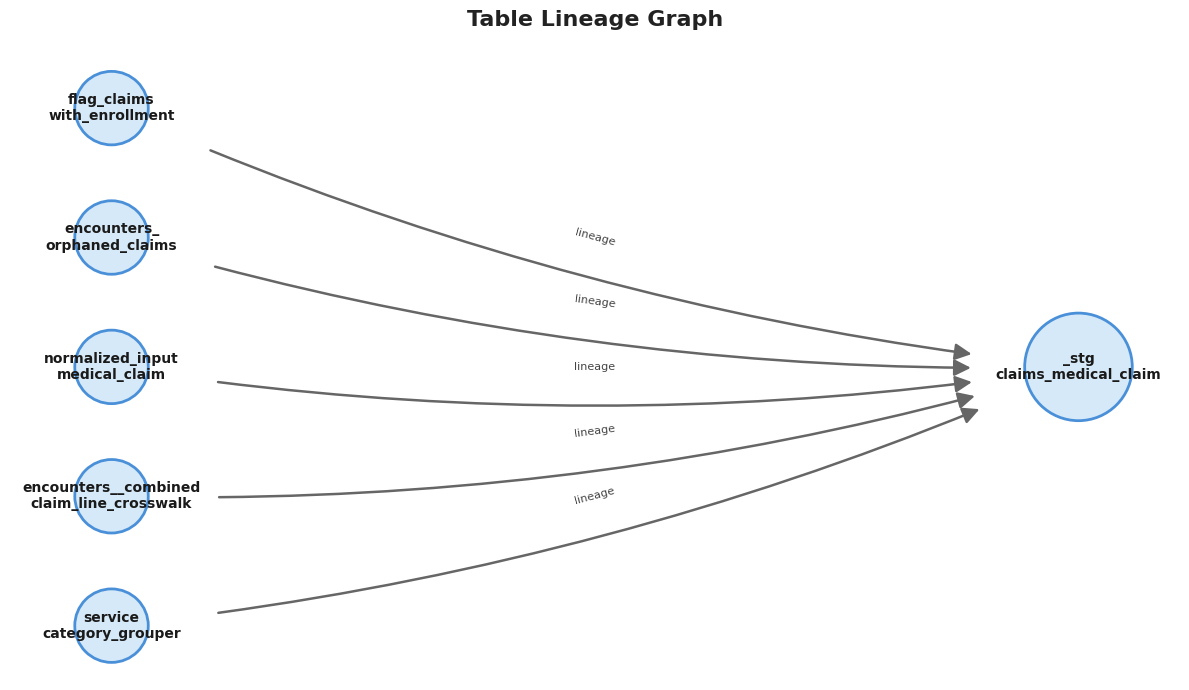

[Round 2] Tool result: Lineage graph rendered: 6 nodes (_stg_claims_medical_claim, flag_claims_with_enrollment, encounters__orphaned_claims, service_category_grouper, normalized_input_medical_claim, encounters__combined_claim_line_crosswalk), 5 edges.

[Round 3] Tool call: execute_gremlin({'gremlin_query': "g.V('table[mcutini_tuva.core._stg_claims_medical_claim]').inE('lineage').project('upstream_table', 'entity_type', 'entity_id').by(outV().id()).by(values('entity_type')).by(values('entity_id')).limit(20)"})
[Round 3] Tool result: [{"entity_id": null, "entity_type": null, "upstream_table": "table[mcutini_tuva.claims_preprocessing.encounters__orphaned_claims]"}, {"entity_id": null, "entity_type": null, "upstream_table": "table[mcutini_tuva.claims_preprocessing.normalized_input_medical_claim]"}, {"entity_id": null, "entity_type": null, "upstream_table": "table[mcutini_tuva.claims_preprocessing.flag_claims_with_enrollment]"}, {"entity_id": null, "entity_type": null, "upstream_table": "ta

In [227]:
AGENT("Show upstream lineage of mcutini_tuva.core._stg_claims_medical_claim. also show lineage entity type")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[407_demo.1_dev.gold_traffic_map_data]').repeat(inE('lineage').outV().simplePath()).emit().path().limit(100)"})
[Round 1] Tool result: g.V('table[407_demo.1_dev.gold_traffic_map_data]').repeat(inE('lineage').outV().simplePath()).emit().path().limit(100)

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V('table[407_demo.1_dev.gold_traffic_map_data]').repeat(inE('lineage').outV().simplePath()).emit().path().limit(100)"})
[Round 2] Tool result: ["path[v[table[407_demo.1_dev.gold_traffic_map_data]], e[lineage[680eb924-ae42-3ca3-8e3a-294ae90af5ee]][table[407_demo.1_dev.gold_traffic_summary]-lineage->table[407_demo.1_dev.gold_traffic_map_data]], v[table[407_demo.1_dev.gold_traffic_summary]]]", "path[v[table[407_demo.1_dev.gold_traffic_map_data]], e[lineage[680eb924-ae42-3ca3-8e3a-294ae90af5ee]][table[407_demo.1_dev.gold_traffic_summary]-lineage->table[407_demo.1_dev.gold_traffic_map_data]], v[table[407_demo.1_dev.go

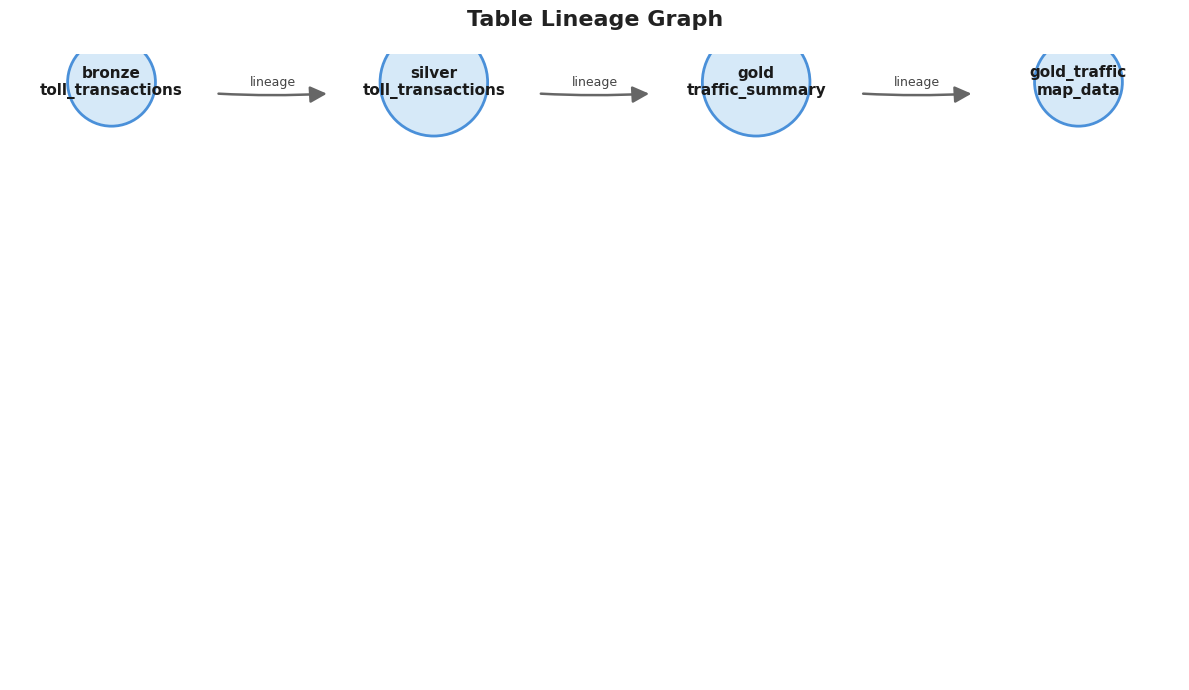

[Round 3] Tool result: Lineage graph rendered: 4 nodes (gold_traffic_map_data, gold_traffic_summary, silver_toll_transactions, bronze_toll_transactions), 3 edges.

Final answer: ## Results

I found **all upstream tables** of `407_demo.1_dev.gold_traffic_map_data` recursively. Here's the complete upstream lineage chain:

### Upstream Dependency Chain:

1. **`407_demo.1_dev.gold_traffic_summary`** (direct upstream)
   - ↑ feeds into `gold_traffic_map_data`

2. **`407_demo.1_dev.silver_toll_transactions`** (2nd level upstream)
   - ↑ feeds into `gold_traffic_summary`

3. **`407_demo.1_dev.bronze_toll_transactions`** (3rd level upstream - root source)
   - ↑ feeds into `silver_toll_transactions`

### Data Flow (from source to target):
```
bronze_toll_transactions 
    → silver_toll_transactions 
        → gold_traffic_summary 
            → gold_traffic_map_data
```

This shows a typical medallion architecture pattern (bronze → silver → gold) where:
- **Bronze** layer contains raw toll tra

In [188]:
AGENT("recurvively Show all upstream tables of 407_demo.1_dev.gold_traffic_map_data ")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[407_demo.1_dev.gold_traffic_map_data]').repeat(bothE('lineage').otherV().simplePath()).emit().path().limit(100)"})
[Round 1] Tool result: g.V('table[407_demo.1_dev.gold_traffic_map_data]').repeat(bothE('lineage').otherV().simplePath()).emit().path().limit(100)

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V('table[407_demo.1_dev.gold_traffic_map_data]').repeat(bothE('lineage').otherV().simplePath()).emit().path().limit(100)"})
[Round 2] Tool result: ["path[v[table[407_demo.1_dev.gold_traffic_map_data]], e[lineage[680eb924-ae42-3ca3-8e3a-294ae90af5ee]][table[407_demo.1_dev.gold_traffic_summary]-lineage->table[407_demo.1_dev.gold_traffic_map_data]], v[table[407_demo.1_dev.gold_traffic_summary]]]", "path[v[table[407_demo.1_dev.gold_traffic_map_data]], e[lineage[680eb924-ae42-3ca3-8e3a-294ae90af5ee]][table[407_demo.1_dev.gold_traffic_summary]-lineage->table[407_demo.1_dev.gold_traffic_map_data]], v[table[407_d

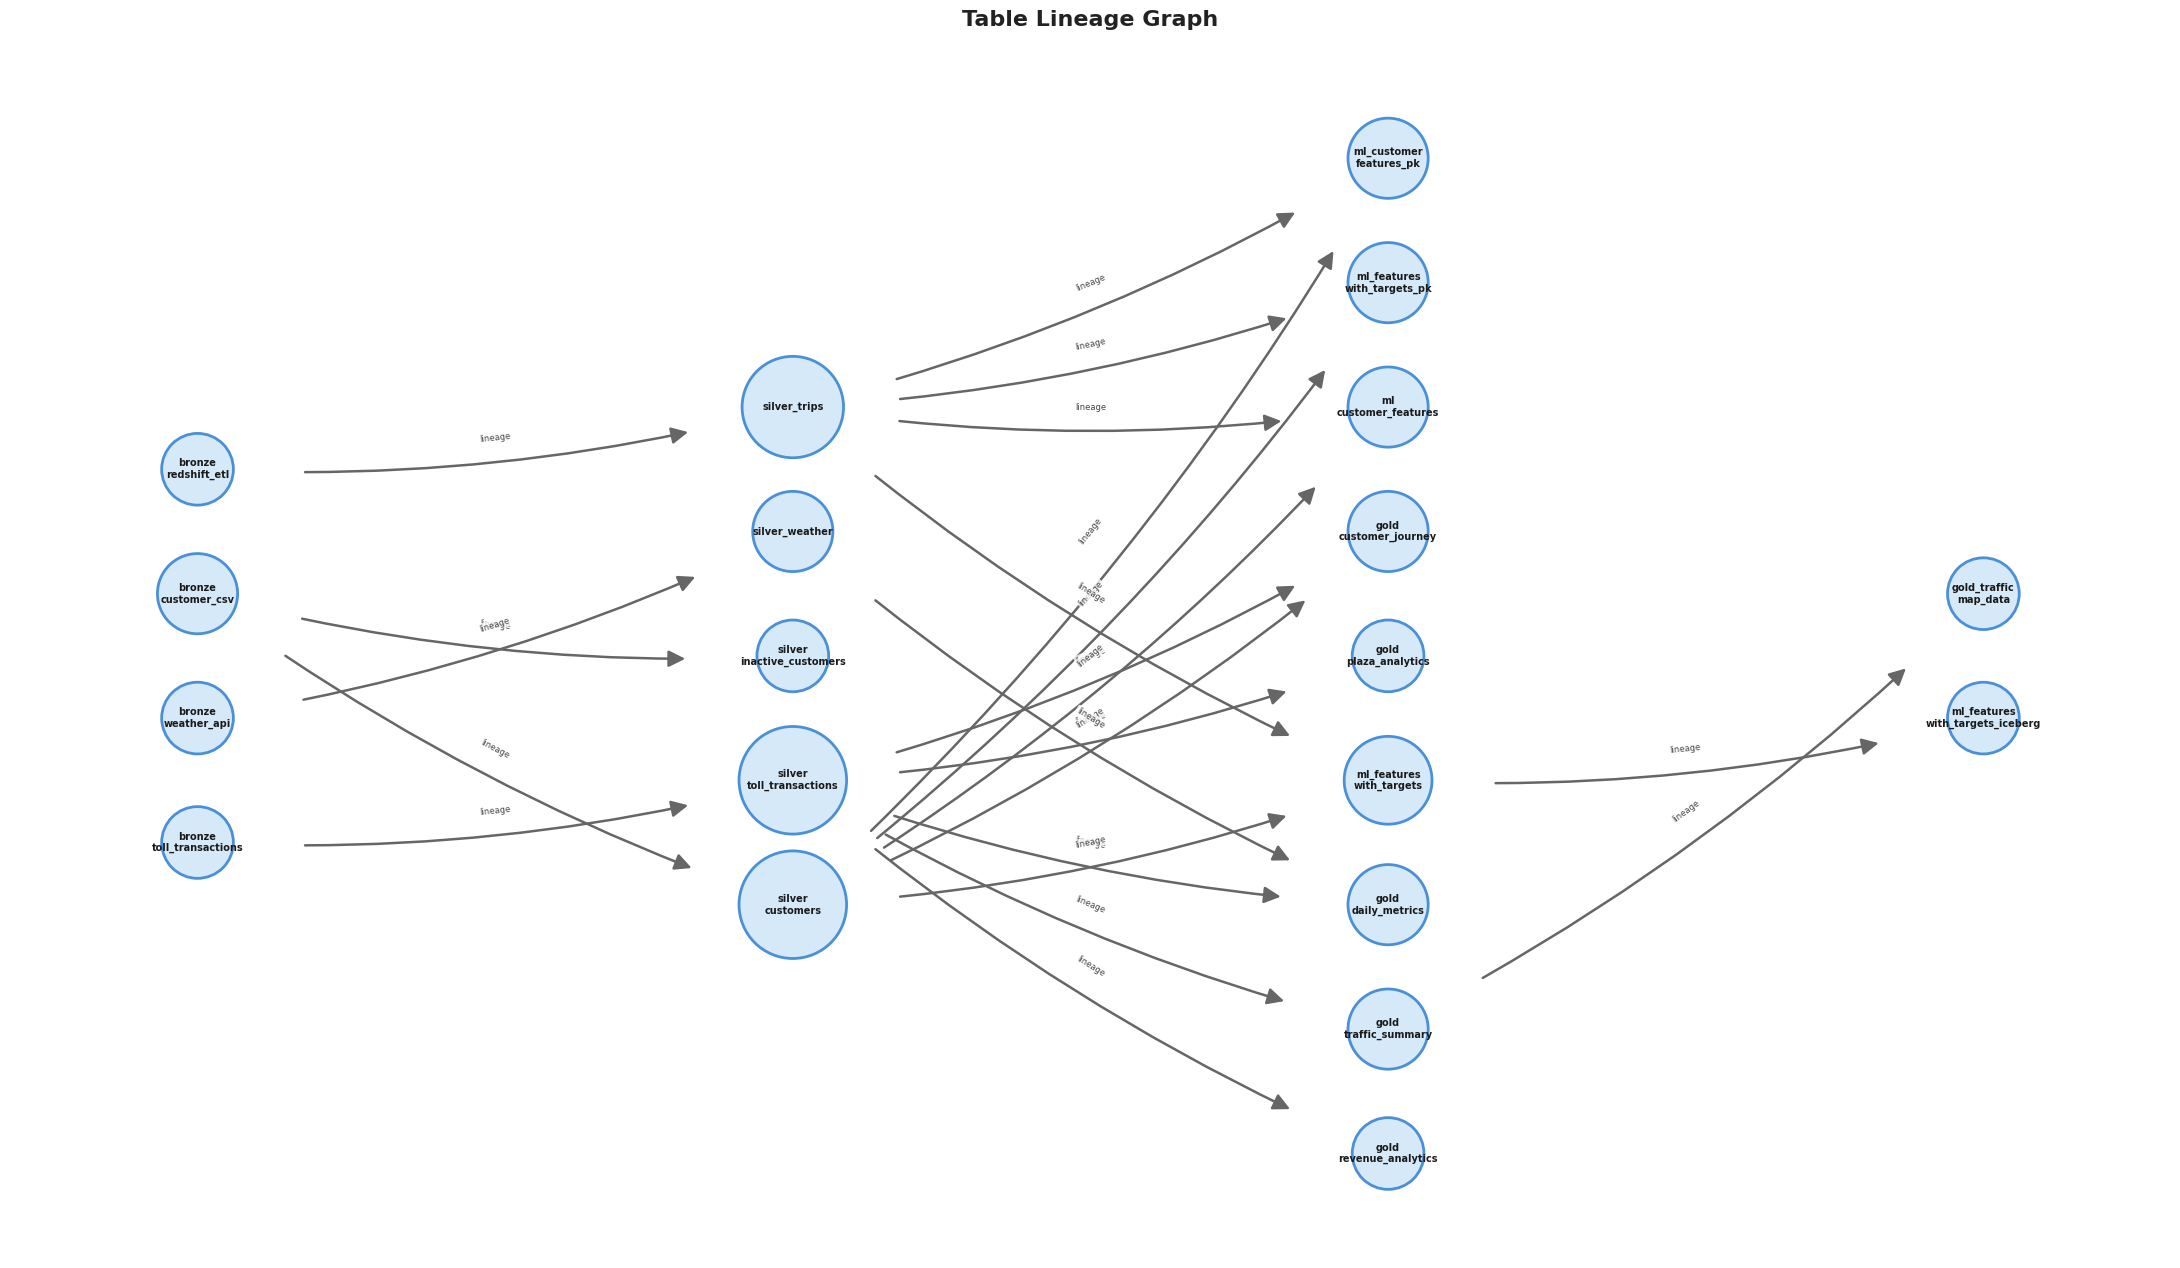

[Round 2] Tool result: Lineage graph rendered: 20 nodes (gold_traffic_map_data, gold_traffic_summary, silver_toll_transactions, gold_customer_journey, bronze_toll_transactions, gold_revenue_analytics, gold_daily_metrics, gold_plaza_analytics, silver_customers, silver_weather, bronze_customer_csv, ml_customer_features_pk, ml_features_with_targets, ml_features_with_targets_pk, ml_customer_features, bronze_weather_api, silver_inactive_customers, silver_trips, ml_features_with_targets_iceberg, bronze_redshift_etl), 22 edges.

Final answer: Perfect! I've successfully retrieved and visualized the complete lineage for `407_demo.1_dev.gold_traffic_map_data`. Here's what I found:

## Connected Tables Summary

The lineage graph shows **20 tables** connected to `gold_traffic_map_data` through **22 lineage relationships**. Here's the breakdown:

### Upstream Dependencies (Data Sources):
1. **gold_traffic_summary** (direct parent)
   - **silver_toll_transactions**
     - **bronze_toll_transactions*

In [189]:
AGENT("recurvively Show all  tables that are connected to 407_demo.1_dev.gold_traffic_map_data and it's lineage")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[00vsdb.agent_analytics.agents_clean]').union(bothE('lineage').path(), outE('created_by').path()).limit(50)"})
[Round 1] Tool result: g.V('table[00vsdb.agent_analytics.agents_clean]').union(bothE('lineage').path(), outE('created_by').path()).limit(50)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('table[00vsdb.agent_analytics.agents_clean]').union(bothE('lineage').path(), outE('created_by').path()).limit(50)"})
[Round 1] Tool result: ["path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[651c8d73-4a3c-35e4-96ab-61df5aa15568]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]]", "path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[dcd982d2-5bd9-351f-bb31-0fca2278c9b9]][table[00vsdb.agent_analytics.agents_bronze]-lineage->table[00vsdb.agent_analytics.agents_clean]]]", "path[v[table[00vsdb.agent_analytics.agents_clean]], e[created_by[null]][tab

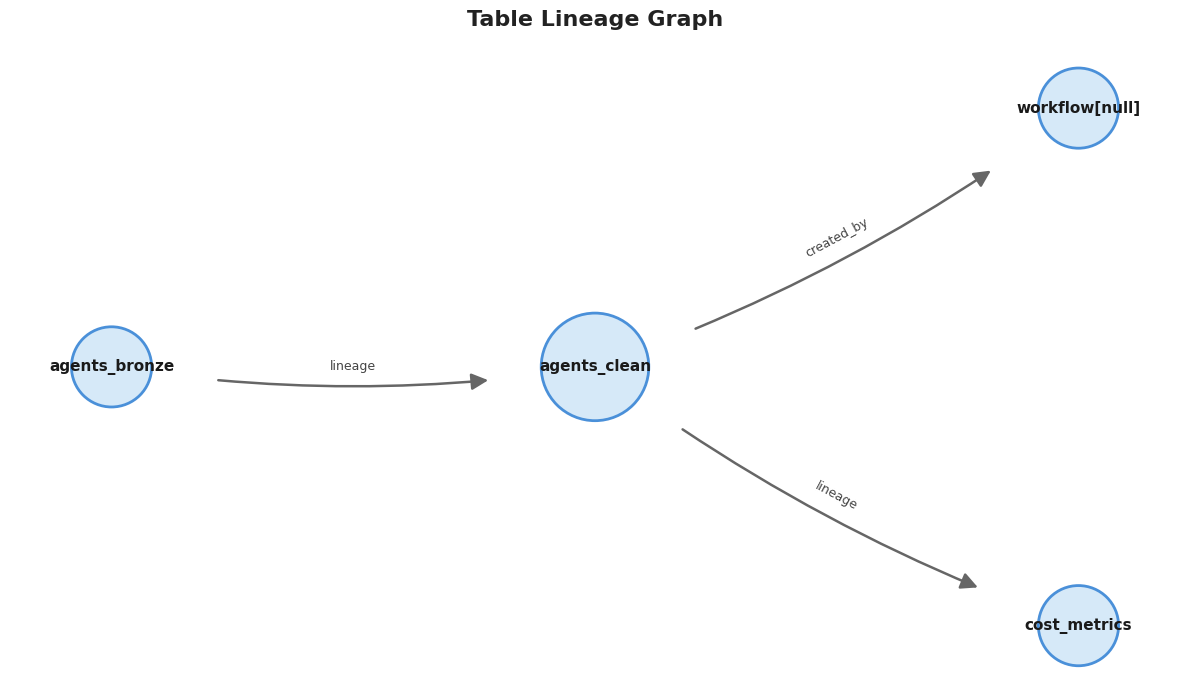

[Round 1] Tool result: Lineage graph rendered: 4 nodes (agents_clean, cost_metrics, agents_bronze, workflow[null]), 3 edges.

Final answer: Perfect! I've retrieved and visualized the complete lineage for the table `00vsdb.agent_analytics.agents_clean` including related workflows.

## Summary of Results:

The lineage graph shows:

### **Tables Connected via Lineage:**
1. **Upstream (source)**: `00vsdb.agent_analytics.agents_bronze` → `agents_clean`
   - The agents_clean table is derived from agents_bronze table

2. **Downstream (target)**: `agents_clean` → `00vsdb.agent_analytics.cost_metrics`
   - The agents_clean table feeds into the cost_metrics table

### **Workflows:**
3. **Created By**: `agents_clean` → `workflow[null]`
   - The agents_clean table was created/transformed by a workflow (the workflow ID appears to be null in the data)

The visualization above shows the complete data flow, with:
- **agents_bronze** as the upstream source
- **agents_clean** as the central table you qu

In [216]:
AGENT("Show lineage of 00vsdb.agent_analytics.agents_clean. include related workflows")

In [215]:
AGENT("Show details of 7281b548-3229-4a52-a9c8-b7eb0068bc90 workflow")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('workflow[7281b548-3229-4a52-a9c8-b7eb0068bc90]').project('workflow_id', 'tables_created').by(id()).by(inE('created_by').outV().id().fold()).limit(1)"})
[Round 1] Tool result: g.V('workflow[7281b548-3229-4a52-a9c8-b7eb0068bc90]').project('workflow_id', 'tables_created').by(id()).by(inE('created_by').outV().id().fold()).limit(1)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('workflow[7281b548-3229-4a52-a9c8-b7eb0068bc90]').project('workflow_id', 'tables_created').by(id()).by(inE('created_by').outV().id().fold()).limit(1)"})
[Round 1] Tool result: [{"tables_created": ["table[advaitgodbole.benchmark_iceberg.time_key_lookup]", "table[advaitgodbole.benchmark_iceberg.store_key_lookup]", "table[advaitgodbole.benchmark_iceberg.customer_key_lookup]", "table[advaitgodbole.benchmark_iceberg.product_dim]", "table[advaitgodbole.benchmark_iceberg.product_key_lookup]", "table[advaitgodbole.benchmark_iceberg.promotion_dim]", "

In [220]:
AGENT("What workflows create the most tables. show top 10")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('workflow').project('workflow_id', 'table_count').by(id()).by(inE('created_by').count()).order().by(select('table_count'), desc).limit(10)"})
[Round 1] Tool result: g.V().hasLabel('workflow').project('workflow_id', 'table_count').by(id()).by(inE('created_by').count()).order().by(select('table_count'), desc).limit(10)

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('workflow').project('workflow_id', 'table_count').by(id()).by(inE('created_by').count()).order().by(select('table_count'), desc).limit(10)"})
[Round 2] Tool result: [{"table_count": 4000, "workflow_id": "workflow[757446051727737]"}, {"table_count": 1600, "workflow_id": "workflow[512942556809993]"}, {"table_count": 1415, "workflow_id": "workflow[661733537865717]"}, {"table_count": 982, "workflow_id": "workflow[9cbfe9e6-11c3-4706-8c2f-43226a44ab14]"}, {"table_count": 980, "workflow_id": "workflow[12d4ec17-d14e-4c5f-aeb6-b4f20e81ad89]

In [231]:
AGENT("What workflows create less than 5 tables. show top 10")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('workflow').project('workflow_id', 'table_count').by(id()).by(inE('created_by').count()).where(select('table_count').is(lt(5))).order().by(select('table_count'), desc).limit(10)"})
[Round 1] Tool result: g.V().hasLabel('workflow').project('workflow_id', 'table_count').by(id()).by(inE('created_by').count()).where(select('table_count').is(lt(5))).order().by(select('table_count'), desc).limit(10)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('workflow').project('workflow_id', 'table_count').by(id()).by(inE('created_by').count()).where(select('table_count').is(lt(5))).order().by(select('table_count'), desc).limit(10)"})
[Round 1] Tool result: [{"table_count": 4, "workflow_id": "workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]"}, {"table_count": 4, "workflow_id": "workflow[1b9efb4c-bfa2-4842-899d-b4f9d9863ab1]"}, {"table_count": 4, "workflow_id": "workflow[1aed5d89-b871-42e3-a1d0-88e2631b0397]"},

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().path()"})
[Round 1] Tool result: g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().path()

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().path()"})
[Round 1] Tool result: ["path[v[workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]], e[created_by[1bd31995-03a1-4237-9bc6-b01739ce47e9]][table[tpcdi.leo_mao_tpcdi_dbsql_10000.dimcompany]-created_by->workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]], v[table[tpcdi.leo_mao_tpcdi_dbsql_10000.dimcompany]]]", "path[v[workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]], e[created_by[1bd31995-03a1-4237-9bc6-b01739ce47e9]][table[tpcdi.leo_mao_tpcdi_dbsql_10000.dimdate]-created_by->workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]], v[table[tpcdi.leo_mao_tpcdi_dbsql_10000.dimdate]]]", "path[v[workflow[1bd31995-03a

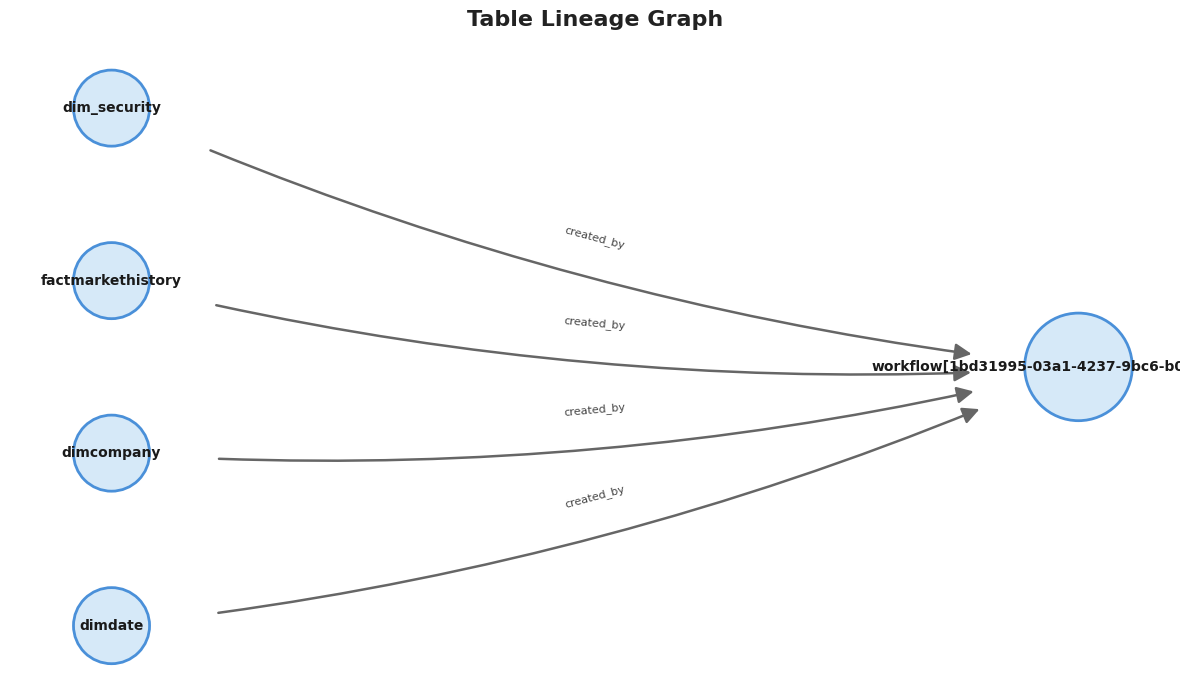

[Round 1] Tool result: Lineage graph rendered: 5 nodes (workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9], dimdate, dim_security, factmarkethistory, dimcompany), 4 edges.

Final answer: Perfect! The workflow `1bd31995-03a1-4237-9bc6-b01739ce47e9` affects **4 tables**:

1. **tpcdi.leo_mao_tpcdi_dbsql_10000.dimcompany**
2. **tpcdi.leo_mao_tpcdi_dbsql_10000.dimdate**
3. **tpcdi.leo_mao_tpcdi_dbsql_10000.factmarkethistory**
4. **tpcdi.simone_finelli_tpcdi_dbsql_10_gold_market.dim_security**

These tables are all created or transformed by this workflow, as indicated by the `created_by` edges connecting them to the workflow. The visualization above shows the relationship between the workflow and these four tables.


In [232]:
AGENT("What tables are affected by 1bd31995-03a1-4237-9bc6-b01739ce47e9 workflow?")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().repeat(outE('lineage').inV()).times(2).path().limit(100)"})
[Round 1] Tool result: g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().repeat(outE('lineage').inV()).times(2).path().limit(100)

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().repeat(outE('lineage').inV()).times(2).path().limit(100)"})
[Round 2] Tool result: []

[Round 2] Tool call: visualize_lineage({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().repeat(outE('lineage').inV()).times(2).path().limit(100)"})
[Round 2] Tool result: {"message": "Query returned no results \u2014 nothing to visualize."}

[Round 3] Tool call: execute_gremlin({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').out


Received error message '{'requestId': 'd36e1115-8345-4327-8891-60db56f2fcc9', 'status': {'code': 597, 'message': "startup failed:\nScript37.groovy: 1: [Static type checking] - Cannot call <E2> org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal#union(org.apache.tinkerpop.gremlin.process.traversal.Traversal<? extends java.lang.Object, E2>[]) with arguments [org.apache.tinkerpop.gremlin.process.traversal.Traversal<?, ?>, org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal<org.apache.tinkerpop.gremlin.structure.Vertex, org.apache.tinkerpop.gremlin.structure.Vertex>, org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal<org.apache.tinkerpop.gremlin.structure.Vertex, org.apache.tinkerpop.gremlin.structure.Vertex>]\n @ line 1, column 85.\n   inE('created_by').outV().union(identity(\n                                 ^\n\nScript37.groovy: 1: [Static type checking] - Cannot find matching method java.lang.Object#dedup(). Please check if 

[Round 4] Tool call: execute_gremlin({'gremlin_query': "g.V('workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9]').inE('created_by').outV().union(identity(), outE('lineage').inV(), repeat(outE('lineage').inV()).times(2)).dedup().id().limit(100)"})
[Round 4] Tool result: {"error": "Gremlin query error: 597: startup failed:\nScript37.groovy: 1: [Static type checking] - Cannot call <E2> org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal#union(org.apache.tinkerpop.gremlin.process.traversal.Traversal<? extends java.lang.Object, E2>[]) with arguments [org.apache.tinkerpop.gremlin.process.traversal.Traversal<?, ?>, org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal<org.apache.tinkerpop.gremlin.structure.Vertex, org.apache.tinkerpop.gremlin.structure.Vertex>, org.apache.tinkerpop.gremlin.process.traversal.dsl.graph.GraphTraversal<org.apache.tinkerpop.gremlin.structure.Vertex, org.apache.tinkerpop.gremlin.structure.Vertex>]\n @ line 1, column 85.\n   inE('cr

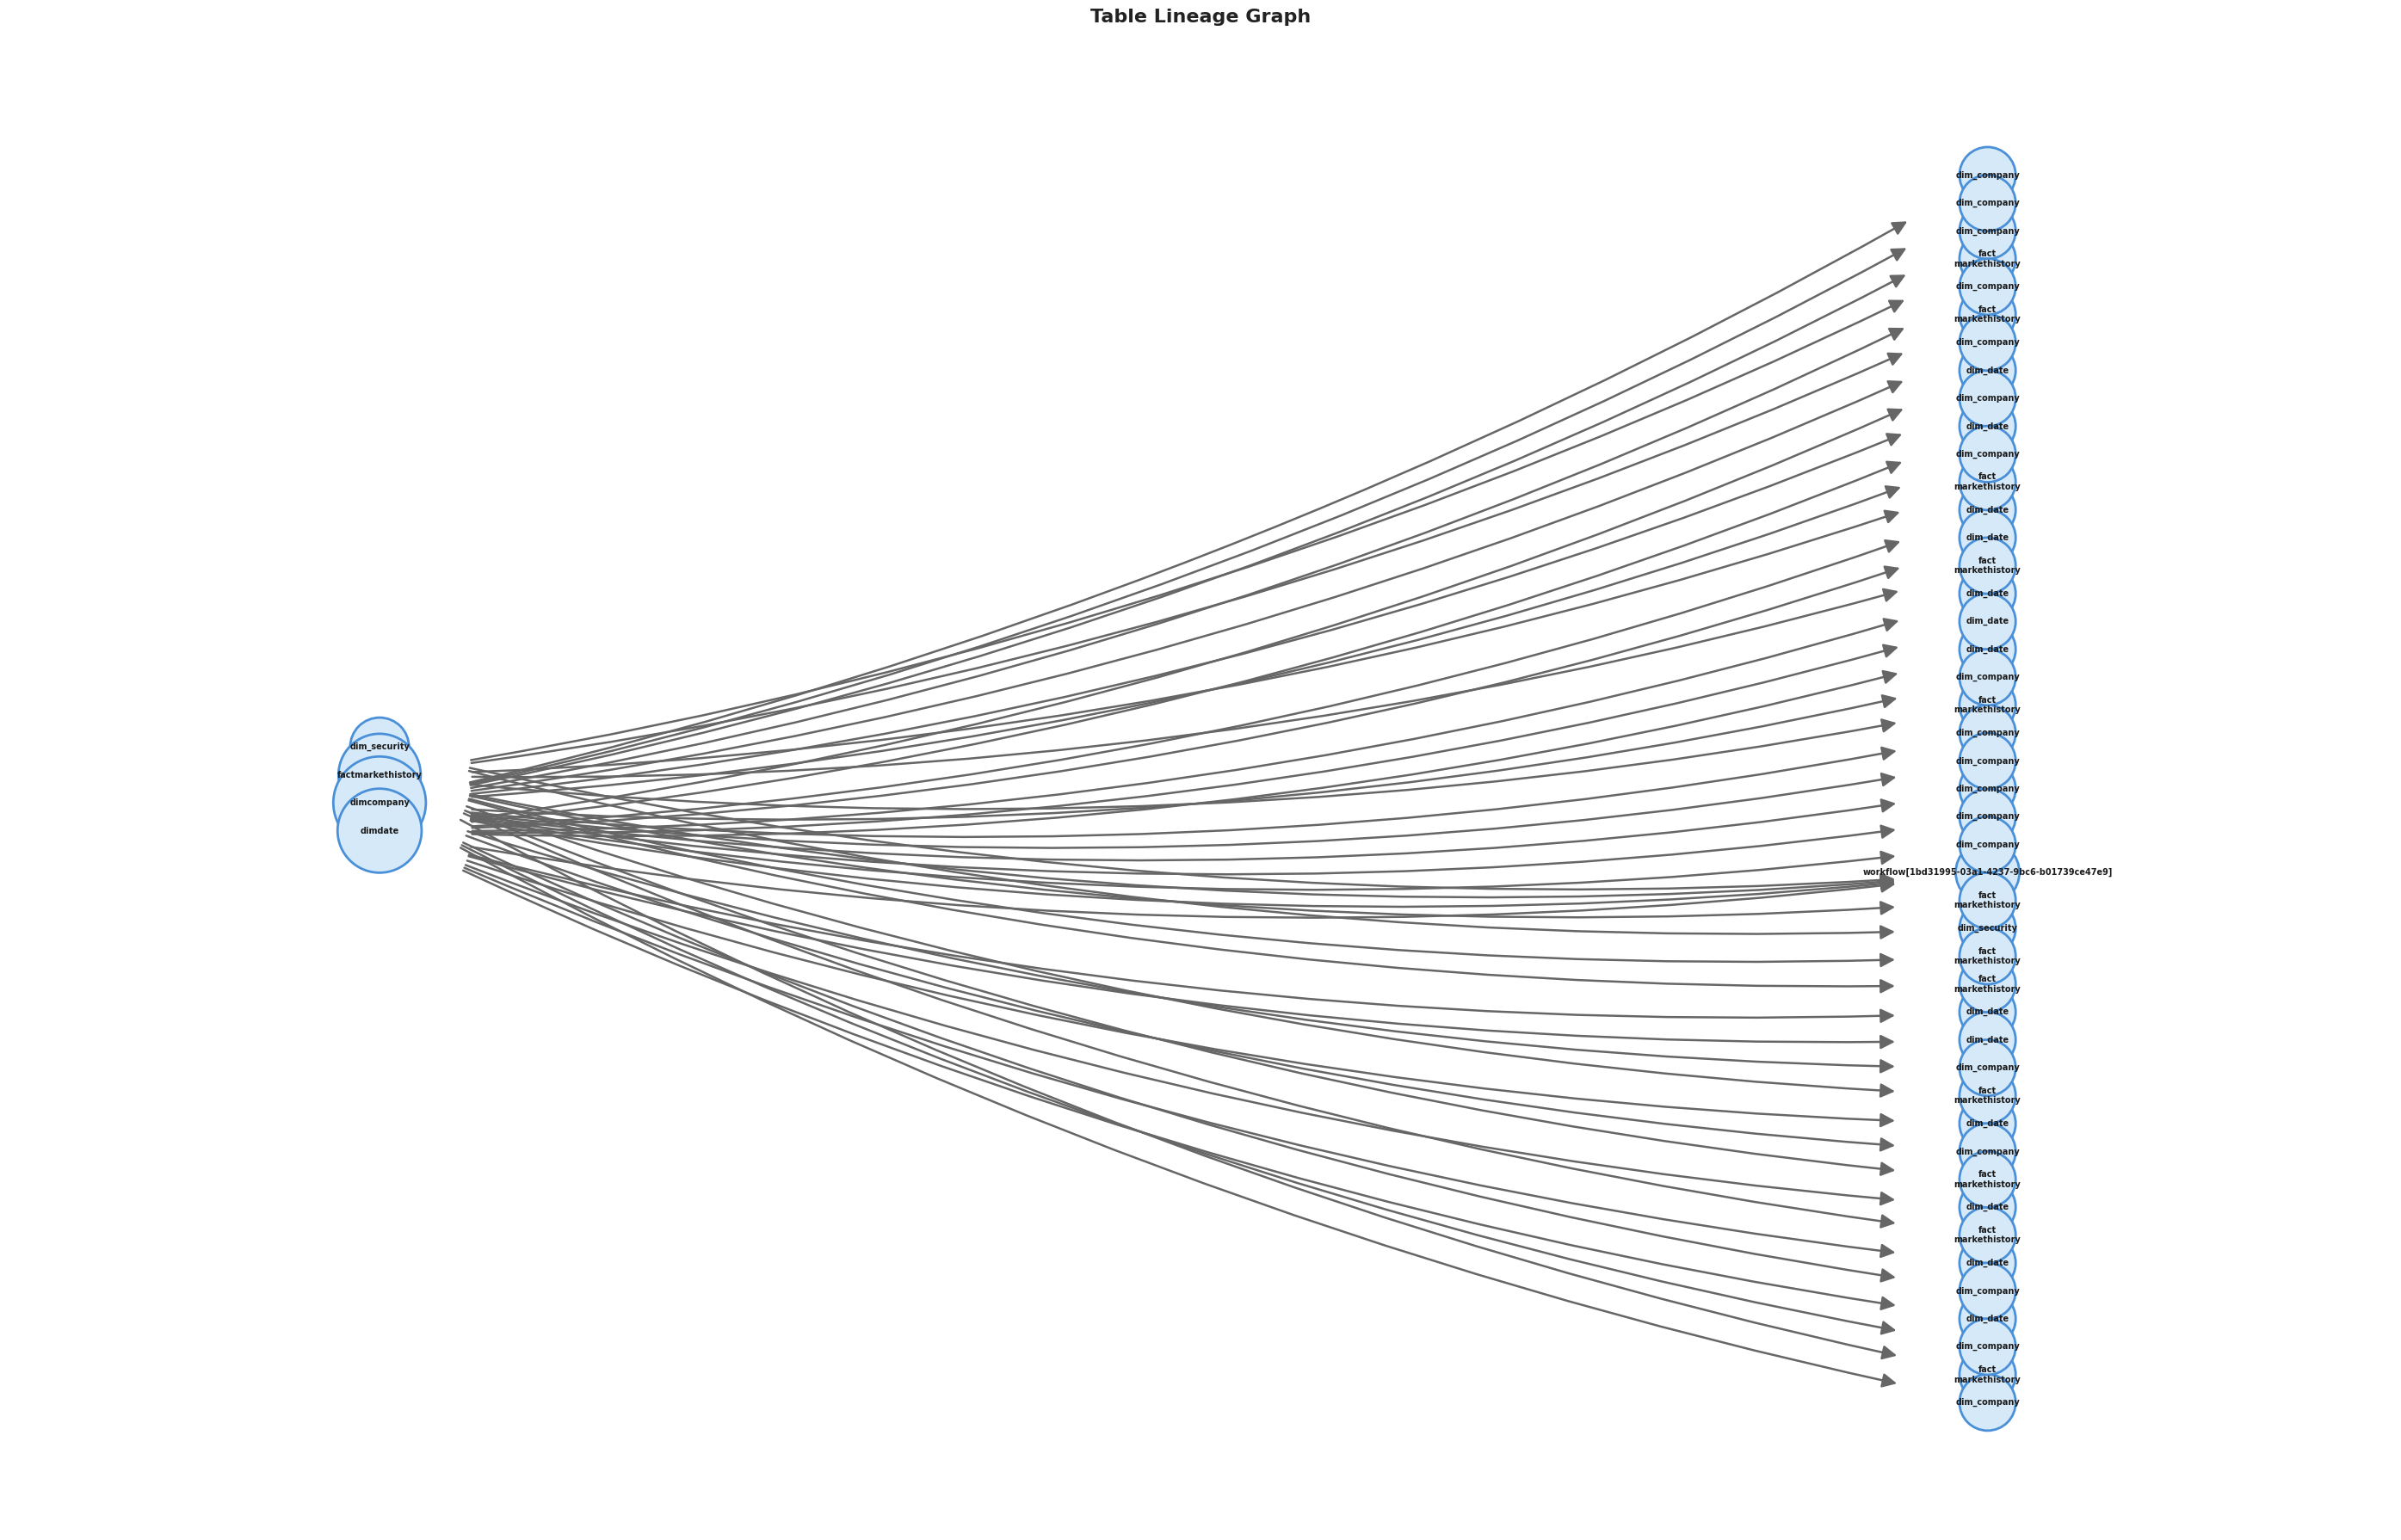

[Round 5] Tool result: Lineage graph rendered: 49 nodes (workflow[1bd31995-03a1-4237-9bc6-b01739ce47e9], dim_security, factmarkethistory, dimcompany, dimdate, dim_security, dim_date, dim_date, dim_date, dim_date, dim_date, dim_date, dim_date, dim_date, dim_date, dim_date, dim_date, dim_date, dim_date, fact_markethistory, fact_markethistory, fact_markethistory, fact_markethistory, fact_markethistory, fact_markethistory, fact_markethistory, fact_markethistory, fact_markethistory, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, dim_company, fact_markethistory, fact_markethistory, fact_markethistory), 48 edges.

⚠ Reached max tool rounds without a final answer


In [234]:
AGENT("What tables are affected by 1bd31995-03a1-4237-9bc6-b01739ce47e9 workflow? Recusively show all tables until 2 levels")